# Forecasting (Stretch Goal)

As a next step, I look into what we should expect for sales next quarter: a simple monthly sales forecast using exponential smoothing (Holt-Winters), which handles the strong seasonality found in `trend_timing.ipynb`.

## 1. Data Loading & Prep

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from chart_style import apply_style, BLUE, ORANGE, RED

apply_style()

sales_data = pd.read_csv('data/supermarket_sales.csv')
sales_data = sales_data.dropna()
sales_data['Order Date'] = pd.to_datetime(sales_data['Order Date'], format='%d/%m/%Y')

monthly_sales = sales_data.groupby(
    sales_data['Order Date'].dt.to_period('M')
)['Sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()
monthly_sales = monthly_sales.asfreq('MS')  # ensure a continuous monthly index
monthly_sales

Order Date
2015-01-01     14205.7070
2015-02-01      4519.8920
2015-03-01     55205.7970
2015-04-01     27906.8550
2015-05-01     23644.3030
2015-06-01     34322.9356
2015-07-01     33781.5430
2015-08-01     27117.5365
2015-09-01     81623.5268
2015-10-01     31453.3930
2015-11-01     77907.6607
2015-12-01     68167.0585
2016-01-01     18066.9576
2016-02-01     11951.4110
2016-03-01     32339.3184
2016-04-01     34154.4685
2016-05-01     29959.5305
2016-06-01     23599.3740
2016-07-01     28608.2590
2016-08-01     36818.3422
2016-09-01     63133.6060
2016-10-01     31011.7375
2016-11-01     70129.2995
2016-12-01     74543.6012
2017-01-01     16870.1810
2017-02-01     22978.8150
2017-03-01     51165.0590
2017-04-01     37385.0170
2017-05-01     56656.9080
2017-06-01     39724.4860
2017-07-01     38320.7830
2017-08-01     30542.2003
2017-09-01     69193.3909
2017-10-01     59583.0330
2017-11-01     79066.4958
2017-12-01     95739.1210
2018-01-01     42839.2940
2018-02-01     19920.9974
2

## 2. Fit the model

Holt-Winters exponential smoothing with additive trend and additive seasonality (period=12, since we saw a clear yearly seasonal cycle peaking around November/December).

In [2]:
model = ExponentialSmoothing(
    monthly_sales,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

forecast = model.forecast(3)
forecast

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


2019-01-01    49679.142714
2019-02-01    42710.863849
2019-03-01    72649.304939
Freq: MS, dtype: float64

## 3. Sanity check - actual vs. fitted, on data we already have

Before trusting the forward forecast, check how well the model's fitted values track the known history.

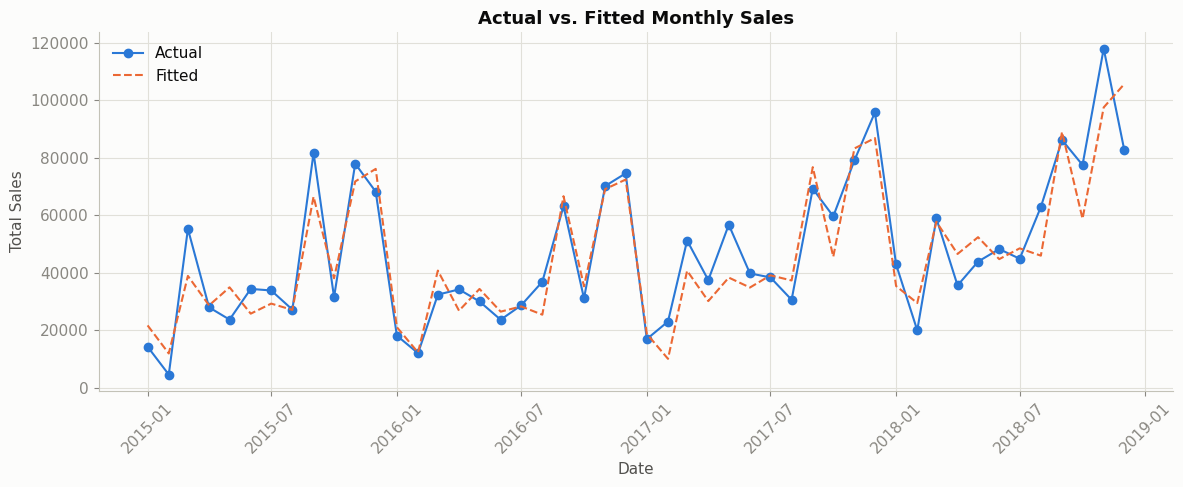

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, label='Actual', marker='o', color=BLUE)
plt.plot(monthly_sales.index, model.fittedvalues, label='Fitted', linestyle='--', color=ORANGE)
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.title('Actual vs. Fitted Monthly Sales')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Forecast next 3 months

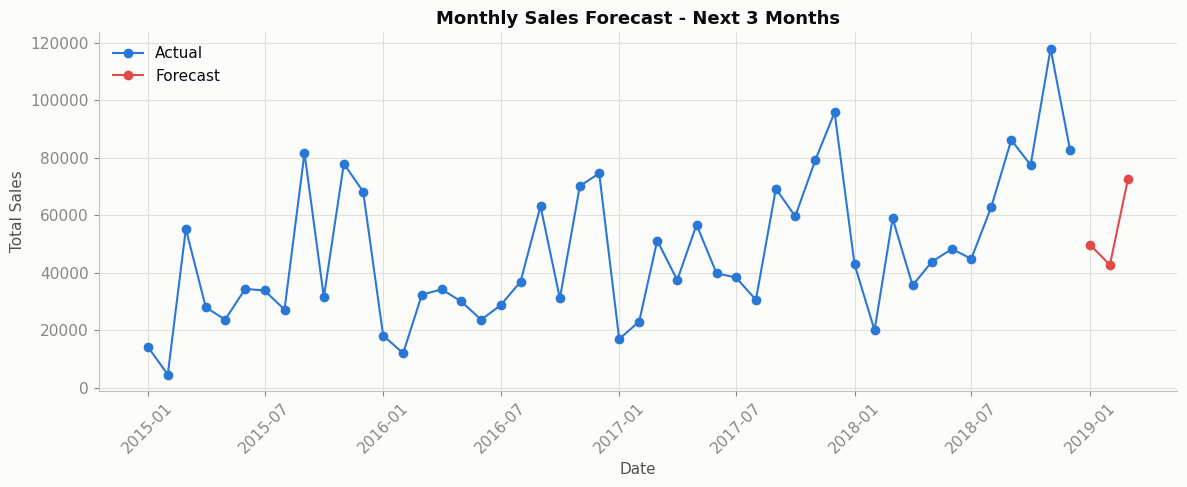

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, label='Actual', marker='o', color=BLUE)
plt.plot(forecast.index, forecast.values, label='Forecast', marker='o', color=RED)
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Forecast - Next 3 Months')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

**Caveats:**
- This forecast assumes the same seasonal pattern and trend seen in 2015–2018 continues unchanged - it doesn't know about planned promotions, new stores, supply disruptions, or anything outside the historical data.
- Only 4 years of history means only 4 observations per calendar month - the seasonal estimate (especially the Nov/Dec spike) is based on a small sample and could be noisy.
- The model fit raised a `ConvergenceWarning` (optimization did not fully converge) - the forecast still ran, but the fitted parameters may not be the true best fit. Worth treating the exact numbers with extra skepticism, or trying alternative starting parameters / a simpler model (e.g. seasonal naive: just repeat last year's month) as a cross-check.
- Treat this as a directional estimate (rough size and seasonal shape of the next quarter), not a precise number to commit to.

## Next Steps

As a next step, I plan to package the best charts and findings from `overall_performance.ipynb`, `segment_analysis.ipynb`, `trend_timing.ipynb`, and this notebook into a one-page summary or dashboard.